# BacterioScope — Pipeline completo de analisis Kirby-Bauer

**Deteccion automatica de discos, medicion de halos de inhibicion y clasificacion CLSI M100-Ed33 (2023) a partir de una fotografia de placa de antibiograma.**

Este notebook contiene el pipeline completo de BacterioScope de forma autocontenida (no requiere instalar el paquete `bacterioscope`, todo el codigo esta incluido aqui). Esta pensado para correr en **Google Colab** con las imagenes y el modelo YOLOv8 entrenado alojados en **Google Drive**.

| Etapa | Metodo |
|---|---|
| 1. Calibracion px/mm | Hough Circle Transform sobre el borde de la placa |
| 2. Deteccion de discos | YOLOv8 (red neuronal) con fallback a Hough Circles |
| 3. Segmentacion de zona | Umbral de Otsu + contornos |
| 4. Clasificacion S/I/R | Tabla de breakpoints CLSI M100-Ed33 (2023), determinista |

Proyecto: **Biodiscovery Design Innovation Challenge (BDIC) 2026** — Universidad de los Andes.
Repositorio: `github.com/EstebanHerna/bacterioscope`

---
## Estructura esperada en Google Drive

Antes de correr este notebook, sube la carpeta `BacterioScope/` (contenida en el ZIP que acompana este notebook) a la raiz de tu Google Drive (**Mi unidad**):

```
Mi unidad/
└── BacterioScope/
    ├── imagenes/              <- placas a analizar (.png, .jpg)
    ├── modelos/
    │   └── yolov8_disks.pt    <- pesos YOLOv8 entrenados (opcional)
    └── resultados/            <- se crea automaticamente, aqui se guardan las salidas
```

Si `modelos/yolov8_disks.pt` no existe, el pipeline usa automaticamente el detector geometrico (Hough Circles) sin fallar.

## 1. Instalacion de dependencias

In [1]:
!pip install -q ultralytics opencv-python-headless scikit-image pandas matplotlib
print("Dependencias instaladas.")

Dependencias instaladas.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Conectar Google Drive

Se solicitara autorizacion la primera vez. Ajusta `DRIVE_BASE` si moviste la carpeta `BacterioScope` a otra ubicacion dentro de tu Drive.

In [2]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE = Path('/content/drive/MyDrive/BacterioScope')
except ImportError:
    # Entorno local (no Colab): usa una carpeta relativa con la misma estructura.
    print("Entorno local detectado (no Google Colab) - usando carpeta local BacterioScope/")
    DRIVE_BASE = Path('BacterioScope')

IMAGES_DIR = DRIVE_BASE / 'imagenes'
WEIGHTS_PATH = DRIVE_BASE / 'modelos' / 'yolov8_disks.pt'
RESULTS_DIR = DRIVE_BASE / 'resultados'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'anotadas').mkdir(exist_ok=True)

print('Imagenes:', IMAGES_DIR, '-> existe:', IMAGES_DIR.exists())
print('Pesos YOLO:', WEIGHTS_PATH, '-> existe:', WEIGHTS_PATH.exists())
print('Resultados se guardaran en:', RESULTS_DIR)

Entorno local detectado (no Google Colab) - usando carpeta local BacterioScope/
Imagenes: BacterioScope\imagenes -> existe: True
Pesos YOLO: BacterioScope\modelos\yolov8_disks.pt -> existe: True
Resultados se guardaran en: BacterioScope\resultados


## 3. Imports y configuracion clinica

In [3]:
from __future__ import annotations

import hashlib
from dataclasses import dataclass, field
from typing import Any

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.typing import NDArray

PLATE_DIAMETER_MM: float = 90.0      # diametro estandar de placa Mueller-Hinton
ORGANISM_GROUP: str = "Enterobacteriaceae"
CONFIDENCE_THRESHOLD: float = 0.04    # bajo porque el modelo esta en entrenamiento temprano
DISK_DIAMETER_MM: float = 6.0         # diametro fisico estandar de un disco de antibiotico

print("Configuracion cargada.")

Configuracion cargada.


## 4. Tabla de breakpoints CLSI M100-Ed33 (2023)

Estandar publicado por el Clinical and Laboratory Standards Institute. Define, para cada antibiotico y grupo de organismos, los diametros minimos de zona de inhibicion (en mm) que distinguen Susceptible / Intermedio / Resistente. **Esta tabla es la fuente de verdad clinica — no es una red neuronal, es una consulta determinista.**

In [4]:
CLSI_2023_ENTEROBACTERIACEAE: dict[str, dict[str, float]] = {
    "meropenem": {"S": 23.0, "I_low": 20.0, "I_high": 22.0, "R": 19.0},
    "imipenem": {"S": 23.0, "I_low": 20.0, "I_high": 22.0, "R": 19.0},
    "ertapenem": {"S": 22.0, "I_low": 19.0, "I_high": 21.0, "R": 18.0},
    "doripenem": {"S": 23.0, "I_low": 20.0, "I_high": 22.0, "R": 19.0},
    "ampicillin": {"S": 17.0, "I_low": 14.0, "I_high": 16.0, "R": 13.0},
    "amoxicillin-clavulanate": {"S": 18.0, "I_low": 14.0, "I_high": 17.0, "R": 13.0},
    "piperacillin-tazobactam": {"S": 21.0, "I_low": 18.0, "I_high": 20.0, "R": 17.0},
    "ceftriaxone": {"S": 23.0, "I_low": 20.0, "I_high": 22.0, "R": 19.0},
    "ceftazidime": {"S": 21.0, "I_low": 18.0, "I_high": 20.0, "R": 17.0},
    "cefepime": {"S": 25.0, "I_low": 19.0, "I_high": 24.0, "R": 18.0},
    "ciprofloxacin": {"S": 26.0, "I_low": 22.0, "I_high": 25.0, "R": 21.0},
    "levofloxacin": {"S": 17.0, "I_low": 14.0, "I_high": 16.0, "R": 13.0},
    "gentamicin": {"S": 15.0, "I_low": 13.0, "I_high": 14.0, "R": 12.0},
    "amikacin": {"S": 17.0, "I_low": 15.0, "I_high": 16.0, "R": 14.0},
    "trimethoprim-sulfamethoxazole": {"S": 16.0, "I_low": 11.0, "I_high": 15.0, "R": 10.0},
}

BREAKPOINT_TABLE_VERSION = "CLSI M100-Ed33 2023"


@dataclass
class SusceptibilityResult:
    antibiotic: str
    zone_diameter_mm: float
    category: str
    breakpoints: dict[str, float]


class CLSIClassifier:
    """Clasifica un diametro de zona en S/I/R usando la tabla CLSI 2023."""

    def __init__(self, organism_group: str = ORGANISM_GROUP) -> None:
        self.organism_group = organism_group
        self.table = CLSI_2023_ENTEROBACTERIACEAE

    def classify(self, antibiotic: str, zone_diameter_mm: float) -> SusceptibilityResult:
        key = antibiotic.lower().strip().replace(" ", "-")
        breakpoints = self.table.get(key, {})
        if not breakpoints:
            category = "UNKNOWN"
        elif zone_diameter_mm >= breakpoints["S"]:
            category = "S"
        elif zone_diameter_mm <= breakpoints.get("R", 0):
            category = "R"
        else:
            category = "I"
        return SusceptibilityResult(antibiotic, zone_diameter_mm, category, breakpoints)


print(f"Tabla CLSI cargada: {len(CLSI_2023_ENTEROBACTERIACEAE)} antibioticos ({BREAKPOINT_TABLE_VERSION}).")

Tabla CLSI cargada: 15 antibioticos (CLSI M100-Ed33 2023).


## 5. Mapeo de clases YOLO (Roboflow/KB-AST) a nombres CLSI

El dataset de entrenamiento usa abreviaturas de laboratorio impresas en el disco (ej. `"CIP 10"` = Ciprofloxacina 10 ug). Este diccionario traduce la clase predicha por YOLOv8 al nombre que la tabla CLSI reconoce.

In [5]:
ROBOFLOW_TO_CLSI: dict[str, str] = {
    "AK 30": "amikacin",
    "APX 30": "ampicillin",
    "AUG 30": "amoxicillin-clavulanate",
    "CAZ 30": "ceftazidime",
    "CIP 10": "ciprofloxacin",
    "CPM 30": "cefepime",
    "CRO 30": "ceftriaxone",
    "CTX 30": "ceftriaxone",
    "GEN 10": "gentamicin",
    "GM 10": "gentamicin",
    "IPM 10": "imipenem",
    "LE 5": "levofloxacin",
    "MEM 10": "meropenem",
    "PTZ 110": "piperacillin-tazobactam",
}

print(f"Mapeo cargado: {len(ROBOFLOW_TO_CLSI)} clases de disco reconocidas.")

Mapeo cargado: 14 clases de disco reconocidas.


## 6. Calibracion — pixeles por milimetro

Detecta el borde circular de la placa con el Hough Circle Transform y calcula `px_per_mm = diametro_placa_px / 90mm`. Sin este paso, la misma medicion en pixeles significaria distancias fisicas distintas segun la distancia de la foto.

In [6]:
def calibrate_px_per_mm(
    image: NDArray[np.uint8],
    plate_diameter_mm: float = PLATE_DIAMETER_MM,
) -> tuple[float, float]:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (15, 15), 3)

    h, w = gray.shape
    min_radius = min(h, w) // 4
    max_radius = min(h, w) // 2

    circles = None
    for param2 in (40, 30, 20):
        circles = cv2.HoughCircles(
            blurred, cv2.HOUGH_GRADIENT, dp=1.5, minDist=min(h, w),
            param1=80, param2=param2, minRadius=min_radius, maxRadius=max_radius,
        )
        if circles is not None:
            break

    if circles is not None:
        circles = np.around(circles).astype(np.uint16)
        largest = max(circles[0], key=lambda c: c[2])
        plate_diameter_px = float(largest[2]) * 2
    else:
        plate_diameter_px = float(min(h, w)) * 0.9

    px_per_mm = plate_diameter_px / plate_diameter_mm
    return plate_diameter_px, px_per_mm


print("Funcion de calibracion lista.")

Funcion de calibracion lista.


## 7. Deteccion de discos — YOLOv8 (red neuronal) + Hough fallback

Si existen pesos entrenados en `modelos/yolov8_disks.pt`, se usa YOLOv8 para localizar cada disco y leer su etiqueta impresa. Si YOLOv8 no detecta ningun disco (modelo aun en entrenamiento temprano, o sin pesos), se usa el detector geometrico Hough Circles como respaldo — el pipeline nunca falla por falta de un modelo entrenado.

In [7]:
@dataclass
class DiskResult:
    label: str
    center_x: int
    center_y: int
    radius_px: int
    confidence: float
    bbox: tuple[int, int, int, int]


class DiskDetector:
    """Detecta discos de antibiotico. YOLOv8 si hay pesos, si no Hough Circles."""

    def __init__(self, weights: Path, confidence: float = CONFIDENCE_THRESHOLD) -> None:
        self.weights = weights
        self.confidence = confidence
        self._model: Any = None
        self._tried_load = False

    def _load_model(self) -> None:
        if self._tried_load:
            return
        self._tried_load = True
        if self.weights.exists():
            from ultralytics import YOLO
            self._model = YOLO(str(self.weights))
            print(f"  YOLOv8 cargado desde {self.weights.name}")
        else:
            print("  Sin pesos YOLOv8 -> usando Hough Circles (geometrico)")

    def detect(self, image: NDArray[np.uint8]) -> list[DiskResult]:
        self._load_model()
        if self._model is not None:
            yolo_results = self._detect_yolo(image)
            if yolo_results:
                return yolo_results
        return self._detect_hough(image)

    def _detect_yolo(self, image: NDArray[np.uint8]) -> list[DiskResult]:
        results = self._model(image, conf=self.confidence, verbose=False)
        disks: list[DiskResult] = []
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
                radius = max(x2 - x1, y2 - y1) // 2
                raw_label = r.names[int(box.cls[0])]
                label = ROBOFLOW_TO_CLSI.get(raw_label, raw_label)
                disks.append(DiskResult(label, cx, cy, radius, float(box.conf[0]), (x1, y1, x2, y2)))
        return disks

    def _detect_hough(self, image: NDArray[np.uint8]) -> list[DiskResult]:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (9, 9), 2)
        circles = cv2.HoughCircles(
            blurred, cv2.HOUGH_GRADIENT, dp=1.2, minDist=50,
            param1=50, param2=20, minRadius=10, maxRadius=40,
        )
        disks: list[DiskResult] = []
        if circles is not None:
            circles = np.around(circles).astype(np.uint16)
            for i, (cx, cy, r) in enumerate(circles[0]):
                disks.append(DiskResult(
                    f"disk_{i}", int(cx), int(cy), int(r), 0.0,
                    (int(cx - r), int(cy - r), int(cx + r), int(cy + r)),
                ))
        return disks


print("Detector de discos listo.")

Detector de discos listo.


## 8. Segmentacion de zona de inhibicion — Otsu + contornos

Para cada disco detectado: recorta una region de interes a su alrededor, aplica umbral de Otsu para separar la zona clara de inhibicion del cesped bacteriano, y mide el diametro del contorno resultante.

In [8]:
@dataclass
class ZoneResult:
    disk_label: str
    center_x: int
    center_y: int
    radius_px: float
    diameter_px: float
    diameter_mm: float
    area_px: float
    circularity: float
    mask: NDArray[np.uint8] | None = None


class ZoneSegmenter:
    def __init__(self, margin_factor: float = 4.0, use_clahe: bool = True) -> None:
        self.margin_factor = margin_factor
        self.use_clahe = use_clahe
        self._clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def segment(self, image: NDArray[np.uint8], disk: DiskResult, px_per_mm: float) -> ZoneResult:
        search_radius = int(disk.radius_px * self.margin_factor)
        roi, ox, oy = self._extract_roi(image, disk, search_radius)

        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        if self.use_clahe:
            gray = self._clahe.apply(gray)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return self._no_zone(disk)

        dlx, dly = disk.center_x - ox, disk.center_y - oy
        best = self._closest_contour(contours, dlx, dly)
        if best is None:
            return self._no_zone(disk)

        area = cv2.contourArea(best)
        perimeter = cv2.arcLength(best, True)
        circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0.0
        (cx, cy), radius = cv2.minEnclosingCircle(best)
        diameter_px = radius * 2
        diameter_mm = diameter_px / px_per_mm

        mask = np.zeros(image.shape[:2], dtype=np.uint8)
        shifted = best + np.array([ox, oy])
        cv2.drawContours(mask, [shifted], -1, 255, -1)

        return ZoneResult(
            disk.label, int(cx) + ox, int(cy) + oy, float(radius),
            float(diameter_px), float(diameter_mm), float(area), float(circularity), mask,
        )

    def _extract_roi(self, image, disk, search_radius):
        h, w = image.shape[:2]
        x1, y1 = max(0, disk.center_x - search_radius), max(0, disk.center_y - search_radius)
        x2, y2 = min(w, disk.center_x + search_radius), min(h, disk.center_y + search_radius)
        return image[y1:y2, x1:x2], x1, y1

    def _closest_contour(self, contours, dx, dy):
        best, best_dist = None, float("inf")
        for c in contours:
            m = cv2.moments(c)
            if m["m00"] == 0:
                continue
            cx, cy = int(m["m10"] / m["m00"]), int(m["m01"] / m["m00"])
            dist = np.sqrt((cx - dx) ** 2 + (cy - dy) ** 2)
            if dist < best_dist:
                best_dist, best = dist, c
        return best

    def _no_zone(self, disk: DiskResult) -> ZoneResult:
        return ZoneResult(disk.label, disk.center_x, disk.center_y, 0.0, 0.0, 0.0, 0.0, 0.0, None)


print("Segmentador de zonas listo.")

Segmentador de zonas listo.


## 9. Visualizacion — anotar la placa con resultados

In [9]:
_CAT_COLOR_BGR = {"S": (106, 200, 120), "I": (80, 185, 230), "R": (100, 110, 240), "UNKNOWN": (170, 170, 170)}


def draw_results(
    image: NDArray[np.uint8],
    disks: list[DiskResult],
    zones: list[ZoneResult],
    classifications: list[SusceptibilityResult],
) -> NDArray[np.uint8]:
    out = image.copy()
    for disk, zone, cls in zip(disks, zones, classifications):
        color = _CAT_COLOR_BGR.get(cls.category, _CAT_COLOR_BGR["UNKNOWN"])
        cv2.circle(out, (disk.center_x, disk.center_y), disk.radius_px, (230, 230, 222), 2)
        if zone.radius_px > 0:
            cv2.circle(out, (zone.center_x, zone.center_y), int(zone.radius_px), color, 2)
        label = f"{disk.label[:18]}: {zone.diameter_mm:.1f}mm ({cls.category})"
        cv2.putText(out, label, (disk.center_x - 60, disk.center_y - disk.radius_px - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2, cv2.LINE_AA)
    return out


print("Funcion de visualizacion lista.")

Funcion de visualizacion lista.

## 10. Pipeline orquestador

Une todas las etapas: calibracion -> deteccion -> segmentacion -> clasificacion -> anotacion.

In [10]:
@dataclass
class AnalysisResult:
    image_path: str
    px_per_mm: float
    disks: list[DiskResult] = field(default_factory=list)
    zones: list[ZoneResult] = field(default_factory=list)
    classifications: list[SusceptibilityResult] = field(default_factory=list)
    annotated_image: NDArray[np.uint8] | None = None


detector = DiskDetector(weights=WEIGHTS_PATH, confidence=CONFIDENCE_THRESHOLD)
segmenter = ZoneSegmenter()
classifier = CLSIClassifier()


def analyze_plate(image_path: Path) -> AnalysisResult:
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"No se pudo leer la imagen: {image_path}")

    _, px_per_mm = calibrate_px_per_mm(image)
    disks = detector.detect(image)

    zones, classifications = [], []
    for disk in disks:
        zone = segmenter.segment(image, disk, px_per_mm)
        cls = classifier.classify(disk.label, zone.diameter_mm)
        zones.append(zone)
        classifications.append(cls)

    annotated = draw_results(image, disks, zones, classifications)
    return AnalysisResult(str(image_path), px_per_mm, disks, zones, classifications, annotated)


print("Pipeline listo. Funcion principal: analyze_plate(ruta_imagen)")

Pipeline listo. Funcion principal: analyze_plate(ruta_imagen)


## 11. Cargar y explorar las imagenes disponibles en Drive

12 imagenes encontradas en BacterioScope\imagenes:


 - plate_12disk_panel.png
 - plate_carbapenem_resistant.png
 - plate_esbl_like.png
 - plate_large_zones.png
 - plate_mdr_organism.png
 - plate_mixed_sir.png
 - plate_pan_susceptible.png
 - plate_uneven_light.png
 - real_plate_01.jpg
 - real_plate_02.jpg
 - real_plate_03_esbl.jpg
 - real_plate_04.jpg


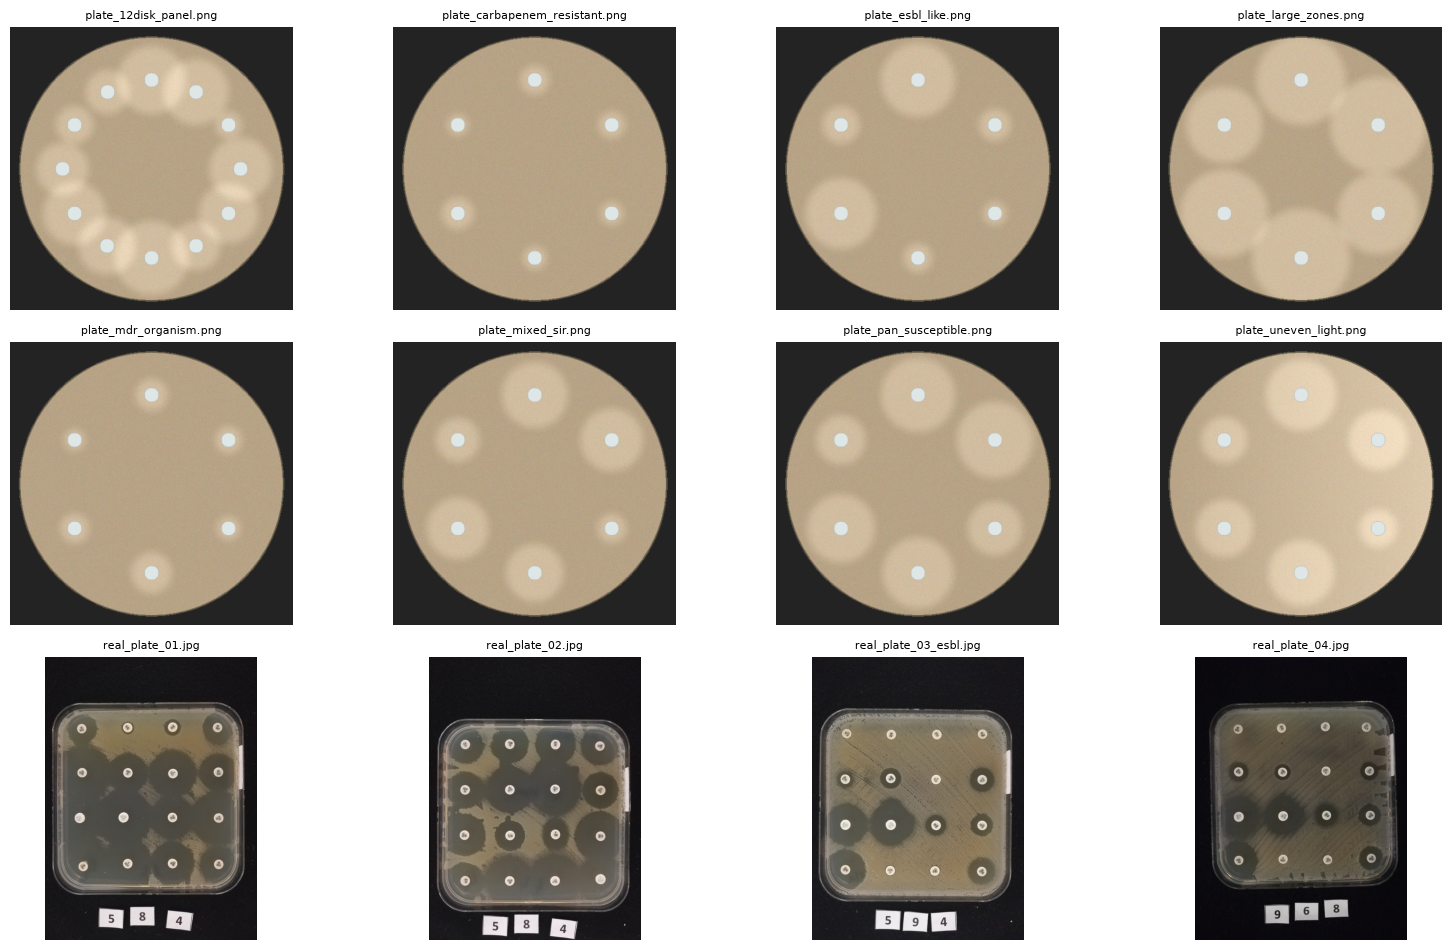

In [11]:
VALID_EXT = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}
image_paths = sorted(p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in VALID_EXT)

print(f"{len(image_paths)} imagenes encontradas en {IMAGES_DIR}:")
for p in image_paths:
    print(" -", p.name)

n = len(image_paths)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.2 * rows))
axes = np.array(axes).reshape(-1)
for ax, p in zip(axes, image_paths):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(p.name, fontsize=8)
    ax.axis("off")
for ax in axes[len(image_paths):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 12. Ejecutar el pipeline sobre todas las imagenes

In [12]:
results: list[AnalysisResult] = []

for path in image_paths:
    print(f"Analizando {path.name} ...")
    try:
        result = analyze_plate(path)
        results.append(result)
        print(f"  -> {len(result.disks)} discos detectados, px_per_mm={result.px_per_mm:.2f}")
    except Exception as exc:
        print(f"  ERROR: {exc}")

print(f"\nCompletado: {len(results)}/{len(image_paths)} placas analizadas.")

Analizando plate_12disk_panel.png ...


  YOLOv8 cargado desde yolov8_disks.pt


  -> 12 discos detectados, px_per_mm=5.58
Analizando plate_carbapenem_resistant.png ...
  -> 6 discos detectados, px_per_mm=5.58
Analizando plate_esbl_like.png ...


  -> 6 discos detectados, px_per_mm=5.58
Analizando plate_large_zones.png ...
  -> 6 discos detectados, px_per_mm=5.53
Analizando plate_mdr_organism.png ...


  -> 6 discos detectados, px_per_mm=5.58
Analizando plate_mixed_sir.png ...
  -> 6 discos detectados, px_per_mm=5.58
Analizando plate_pan_susceptible.png ...


  -> 6 discos detectados, px_per_mm=5.53
Analizando plate_uneven_light.png ...
  -> 2 discos detectados, px_per_mm=5.58
Analizando real_plate_01.jpg ...


  -> 166 discos detectados, px_per_mm=28.60
Analizando real_plate_02.jpg ...


  -> 203 discos detectados, px_per_mm=30.89
Analizando real_plate_03_esbl.jpg ...


  -> 269 discos detectados, px_per_mm=31.87
Analizando real_plate_04.jpg ...


  -> 1 discos detectados, px_per_mm=20.44

Completado: 12/12 placas analizadas.


## 13. Visualizar placas anotadas

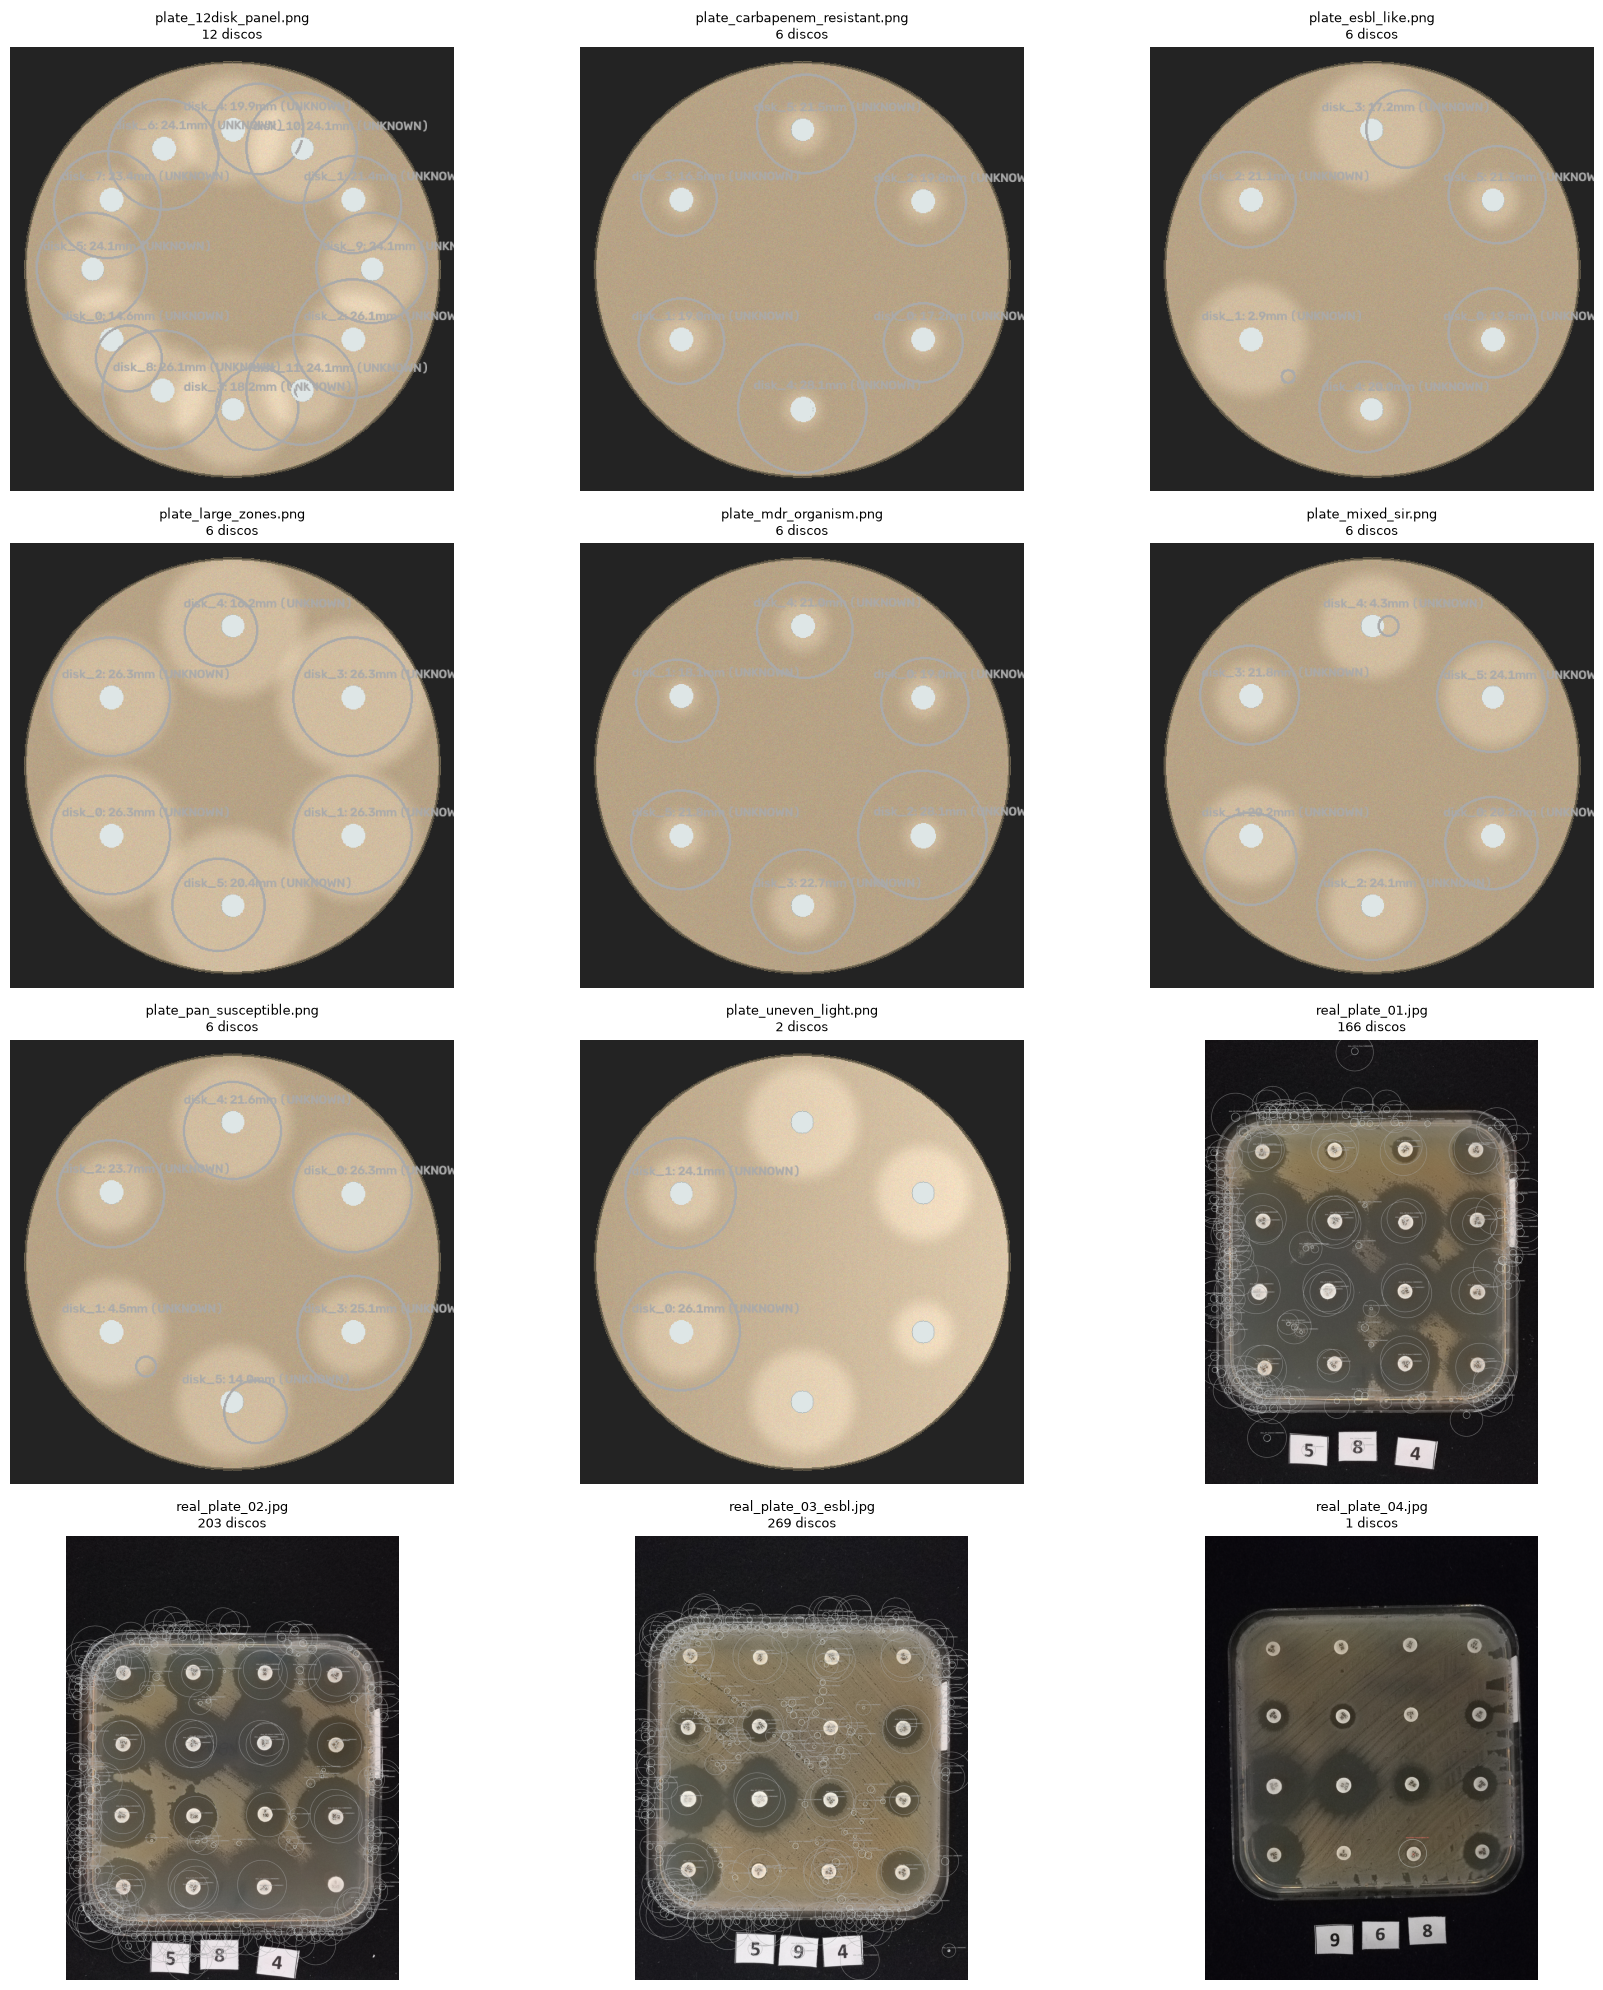

In [13]:
n = len(results)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, results):
    img_rgb = cv2.cvtColor(r.annotated_image, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(f"{Path(r.image_path).name}\n{len(r.disks)} discos", fontsize=9)
    ax.axis("off")
for ax in axes[len(results):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 14. Tabla resumen y estadisticas clinicas

In [14]:
rows = []
for r in results:
    for disk, zone, cls in zip(r.disks, r.zones, r.classifications):
        rows.append({
            "imagen": Path(r.image_path).name,
            "antibiotico": disk.label,
            "confianza_yolo": round(disk.confidence, 3),
            "zona_mm": round(zone.diameter_mm, 1),
            "circularidad": round(zone.circularity, 2),
            "categoria": cls.category,
            "px_per_mm": round(r.px_per_mm, 2),
        })

df = pd.DataFrame(rows)
print(f"Total de discos analizados: {len(df)}")
df.head(20)

Total de discos analizados: 689


,imagen,antibiotico,confianza_yolo,zona_mm,circularidad,categoria,px_per_mm
0,plate_12disk_panel.png,disk_0,0.0,14.6,0.34,UNKNOWN,5.58
1,plate_12disk_panel.png,disk_1,0.0,21.4,0.19,UNKNOWN,5.58
2,plate_12disk_panel.png,disk_2,0.0,26.1,0.40,UNKNOWN,5.58
3,plate_12disk_panel.png,disk_3,0.0,18.2,0.38,UNKNOWN,5.58
4,plate_12disk_panel.png,disk_4,0.0,19.9,0.18,UNKNOWN,5.58
5,plate_12disk_panel.png,disk_5,0.0,24.1,0.79,UNKNOWN,5.58
6,plate_12disk_panel.png,disk_6,0.0,24.1,0.68,UNKNOWN,5.58
7,plate_12disk_panel.png,disk_7,0.0,23.4,0.19,UNKNOWN,5.58
8,plate_12disk_panel.png,disk_8,0.0,26.1,0.79,UNKNOWN,5.58
9,plate_12disk_panel.png,disk_9,0.0,24.1,0.15,UNKNOWN,5.58


Distribucion S / I / R:


categoria
UNKNOWN    688
R            1
Name: count, dtype: int64


Discos por antibiotico identificado:


antibiotico
disk_0                     11
disk_1                     11
disk_2                     10
disk_3                     10
disk_4                     10
                           ..
disk_265                    1
disk_266                    1
disk_267                    1
disk_268                    1
amoxicillin-clavulanate     1
Name: count, Length: 270, dtype: int64

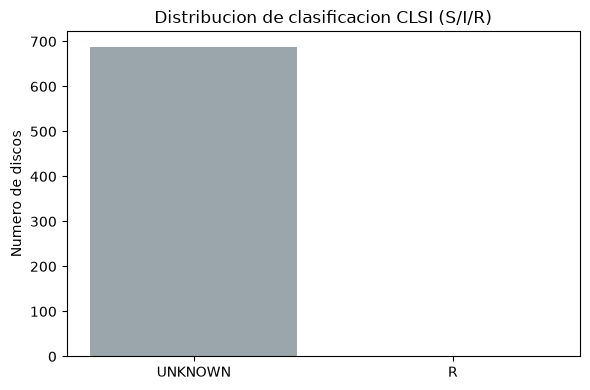

In [15]:
print("Distribucion S / I / R:")
display(df["categoria"].value_counts())

print("\nDiscos por antibiotico identificado:")
display(df["antibiotico"].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
colors = {"S": "#3E8E6B", "I": "#4AA7D9", "R": "#D9646E", "UNKNOWN": "#9AA5AC"}
counts = df["categoria"].value_counts()
ax.bar(counts.index, counts.values, color=[colors.get(c, "#888") for c in counts.index])
ax.set_ylabel("Numero de discos")
ax.set_title("Distribucion de clasificacion CLSI (S/I/R)")
plt.tight_layout()
plt.show()

## 15. Exportar resultados a Google Drive

Guarda el CSV con todas las mediciones y las imagenes anotadas en `BacterioScope/resultados/` dentro de tu Drive, listo para compartir con el equipo.

In [16]:
csv_path = RESULTS_DIR / "resultados_bacterioscope.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"CSV guardado en: {csv_path}")

for r in results:
    name = Path(r.image_path).stem + "_anotada.png"
    out_path = RESULTS_DIR / "anotadas" / name
    cv2.imwrite(str(out_path), r.annotated_image)

print(f"{len(results)} imagenes anotadas guardadas en: {RESULTS_DIR / 'anotadas'}")
print("\nListo. Todos los resultados quedaron en tu Google Drive, carpeta BacterioScope/resultados/.")

CSV guardado en: BacterioScope\resultados\resultados_bacterioscope.csv


12 imagenes anotadas guardadas en: BacterioScope\resultados\anotadas

Listo. Todos los resultados quedaron en tu Google Drive, carpeta BacterioScope/resultados/.


---
## Notas sobre el modelo YOLOv8

- Arquitectura: **YOLOv8n** (nano), 3.0M parametros, entrada 640x640.
- Entrenado por transfer learning desde pesos COCO sobre el dataset Roboflow/KB-AST (102 imagenes de entrenamiento, 29 clases de disco).
- 50 epocas en GPU (RTX 3050), mAP50 final ≈ 0.096 — modelo en fase temprana de entrenamiento.
- Por eso `CONFIDENCE_THRESHOLD = 0.04`: con mas datos de entrenamiento este umbral subira y la deteccion sera mas confiable.
- Si el archivo de pesos no esta presente en Drive, el detector usa automaticamente Hough Circles (metodo geometrico, sin aprendizaje) y el pipeline sigue funcionando sin errores.

## Arquitectura de decision clinica

La clasificacion S/I/R **no usa una red neuronal** — es una tabla de umbrales publicada por el CLSI (Clinical and Laboratory Standards Institute), consultada de forma determinista. Solo la deteccion y lectura del disco usa aprendizaje profundo (YOLOv8); la logica clinica es completamente auditable y trazable a mano por un microbiologo.